<a href="https://colab.research.google.com/github/yuva0567890/23MID0421APAassignment4/blob/main/APA4DATASET2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Load the manually uploaded UCI Online Retail II Excel file
file_name = '/content/online_retail_II.xlsx'

df_2009 = pd.read_excel(file_name, sheet_name='Year 2009-2010')
df_2010 = pd.read_excel(file_name, sheet_name='Year 2010-2011')

print("2009-2010:", df_2009.shape)
print("2010-2011:", df_2010.shape)

2009-2010: (525461, 8)
2010-2011: (541910, 8)


In [ ]:
# Combine both yearly sheets into one dataset
df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Combined Dataset Shape:", df.shape)

Combined Dataset Shape: (1067371, 8)


In [ ]:
# Inspect the combined Online Retail II dataset
print(df.head())
print(df.columns.tolist())
print(df.info())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   

In [ ]:
# Check missing values and duplicate transaction rows
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335


In [ ]:
# Check the number of unique customers and missing customer IDs
print("Unique Customers:", df['Customer ID'].nunique())
print("Missing Customer IDs:", df['Customer ID'].isnull().sum())

Unique Customers: 5942
Missing Customer IDs: 243007


In [ ]:
# Remove transactions that cannot be linked to a customer
df = df.dropna(subset=['Customer ID'])

In [ ]:
# Keep only valid positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [ ]:
# Convert InvoiceDate into datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
# Calculate the total monetary value of each transaction line
df['TotalAmount'] = df['Quantity'] * df['Price']

In [ ]:
# Convert transaction-level data into customer-level behavioural features
customer_df = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (df['InvoiceDate'].max() - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    TotalQuantity=('Quantity', 'sum'),
    AverageOrderValue=('TotalAmount', 'mean'),
    Monetary=('TotalAmount', 'sum'),
    Country=('Country', 'first')
).reset_index()

print(customer_df.head())
print("Customer-level shape:", customer_df.shape)

   Customer ID  Recency  Frequency  TotalQuantity  AverageOrderValue  \
0      12346.0      325         12          74285        2281.072353   
1      12347.0        1          8           3286          22.266087   
2      12348.0       74          5           2714          39.596078   
3      12349.0       18          4           1624          25.306800   
4      12350.0      309          1            197          19.670588   

   Monetary         Country  
0  77556.46  United Kingdom  
1   5633.32         Iceland  
2   2019.40         Finland  
3   4428.69           Italy  
4    334.40          Norway  
Customer-level shape: (5878, 7)


In [ ]:
# Create a binary customer-value target using the median monetary value
threshold = customer_df['Monetary'].median()

customer_df['HighValueCustomer'] = (
    customer_df['Monetary'] >= threshold
).astype(int)

print(customer_df['HighValueCustomer'].value_counts())

HighValueCustomer
1    2939
0    2939
Name: count, dtype: int64


In [ ]:
# Remove customer ID and the target-defining monetary feature to prevent leakage
customer_model_df = customer_df.drop(
    columns=['Customer ID', 'Monetary']
)

print(customer_model_df.head())

   Recency  Frequency  TotalQuantity  AverageOrderValue         Country  \
0      325         12          74285        2281.072353  United Kingdom   
1        1          8           3286          22.266087         Iceland   
2       74          5           2714          39.596078         Finland   
3       18          4           1624          25.306800           Italy   
4      309          1            197          19.670588          Norway   

   HighValueCustomer  
0                  1  
1                  1  
2                  1  
3                  1  
4                  0  


In [ ]:
# Inspect the final customer-level classification dataset
print("Shape:", customer_model_df.shape)
print("\nColumns:")
print(customer_model_df.columns.tolist())

print("\nMissing values:")
print(customer_model_df.isnull().sum())

print("\nTarget distribution:")
print(customer_model_df['HighValueCustomer'].value_counts())

Shape: (5878, 6)

Columns:
['Recency', 'Frequency', 'TotalQuantity', 'AverageOrderValue', 'Country', 'HighValueCustomer']

Missing values:
Recency              0
Frequency            0
TotalQuantity        0
AverageOrderValue    0
Country              0
HighValueCustomer    0
dtype: int64

Target distribution:
HighValueCustomer
1    2939
0    2939
Name: count, dtype: int64


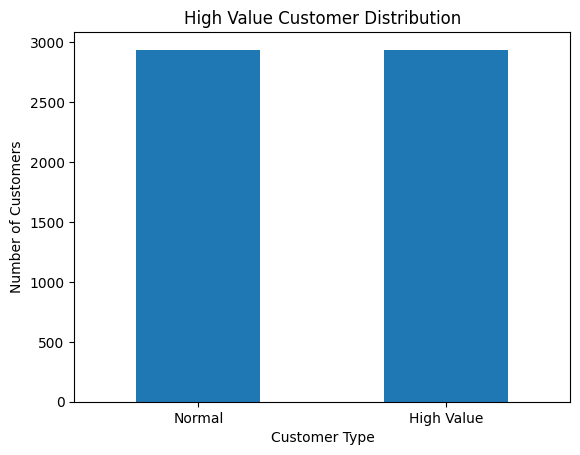

In [ ]:
# Visualize the distribution of high-value and normal-value customers
customer_model_df['HighValueCustomer'].value_counts().plot(kind='bar')

plt.title('High Value Customer Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Normal', 'High Value'], rotation=0)
plt.show()

In [ ]:
# Check the transaction date range for creating a temporal prediction task
print("Start Date:", df['InvoiceDate'].min())
print("End Date:", df['InvoiceDate'].max())

Start Date: 2009-12-01 07:45:00
End Date: 2011-12-09 12:50:00


In [ ]:
# Divide the transactions into historical and future periods
cutoff_date = df['InvoiceDate'].quantile(0.75)

historical_df = df[df['InvoiceDate'] < cutoff_date]
future_df = df[df['InvoiceDate'] >= cutoff_date]

print("Cutoff Date:", cutoff_date)
print("Historical rows:", len(historical_df))
print("Future rows:", len(future_df))

Cutoff Date: 2011-07-28 13:05:00
Historical rows: 604147
Future rows: 201402


In [ ]:
# Create customer behaviour features using only historical transactions
historical_features = historical_df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (historical_df['InvoiceDate'].max() - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    TotalQuantity=('Quantity', 'sum'),
    AverageOrderValue=('TotalAmount', 'mean'),
    Country=('Country', 'first')
).reset_index()

In [ ]:
# Calculate future spending for each customer to define the prediction target
future_spending = future_df.groupby('Customer ID')['TotalAmount'].sum().reset_index()

future_spending.columns = ['Customer ID', 'FutureMonetary']

print(future_spending.head())

   Customer ID  FutureMonetary
0      12347.0         2104.05
1      12348.0          310.00
2      12349.0         1757.55
3      12352.0          944.23
4      12356.0           58.35


In [ ]:
# Combine historical customer features with their future spending
customer_prediction_df = historical_features.merge(
    future_spending,
    on='Customer ID',
    how='left'
)

customer_prediction_df['FutureMonetary'] = (
    customer_prediction_df['FutureMonetary'].fillna(0)
)

print(customer_prediction_df.head())

   Customer ID  Recency  Frequency  TotalQuantity  AverageOrderValue  \
0      12346.0      191         12          74285        2281.072353   
1      12347.0       49          5           2141          20.400405   
2      12348.0      114          4           2497          35.612500   
3      12349.0      273          3            993          26.187647   
4      12350.0      175          1            197          19.670588   

          Country  FutureMonetary  
0  United Kingdom            0.00  
1         Iceland         2104.05  
2         Finland          310.00  
3           Italy         1757.55  
4          Norway            0.00  


In [ ]:
# Define high-value customers using future spending
value_threshold = customer_prediction_df['FutureMonetary'].quantile(0.75)

customer_prediction_df['HighValueCustomer'] = (
    customer_prediction_df['FutureMonetary'] >= value_threshold
).astype(int)

print("Future spending threshold:", value_threshold)
print(customer_prediction_df['HighValueCustomer'].value_counts())

Future spending threshold: 566.735
HighValueCustomer
0    3845
1    1282
Name: count, dtype: int64


In [ ]:
# Remove customer ID and future spending to prevent target leakage
customer_model_df = customer_prediction_df.drop(
    columns=['Customer ID', 'FutureMonetary']
)

print(customer_model_df.head())

   Recency  Frequency  TotalQuantity  AverageOrderValue         Country  \
0      191         12          74285        2281.072353  United Kingdom   
1       49          5           2141          20.400405         Iceland   
2      114          4           2497          35.612500         Finland   
3      273          3            993          26.187647           Italy   
4      175          1            197          19.670588          Norway   

   HighValueCustomer  
0                  0  
1                  1  
2                  0  
3                  1  
4                  0  


In [ ]:
# Check the final features and target
print(customer_model_df.columns.tolist())
print(customer_model_df.info())
print(customer_model_df.isnull().sum())

['Recency', 'Frequency', 'TotalQuantity', 'AverageOrderValue', 'Country', 'HighValueCustomer']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5127 entries, 0 to 5126
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Recency            5127 non-null   int64  
 1   Frequency          5127 non-null   int64  
 2   TotalQuantity      5127 non-null   int64  
 3   AverageOrderValue  5127 non-null   float64
 4   Country            5127 non-null   object 
 5   HighValueCustomer  5127 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 240.5+ KB
None
Recency              0
Frequency            0
TotalQuantity        0
AverageOrderValue    0
Country              0
HighValueCustomer    0
dtype: int64


In [ ]:
# Separate customer features and the prediction target
X2 = customer_model_df.drop(columns=['HighValueCustomer'])
y2 = customer_model_df['HighValueCustomer']

print("Features:", X2.columns.tolist())
print("Target distribution:")
print(y2.value_counts())

Features: ['Recency', 'Frequency', 'TotalQuantity', 'AverageOrderValue', 'Country']
Target distribution:
HighValueCustomer
0    3845
1    1282
Name: count, dtype: int64


In [ ]:
# Create a stratified train-test split for Dataset 2
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

print("Training set:", X2_train.shape)
print("Test set:", X2_test.shape)

Training set: (4101, 5)
Test set: (1026, 5)


In [ ]:
# Identify numerical and categorical features for model-specific preprocessing
num_cols2 = [
    'Recency',
    'Frequency',
    'TotalQuantity',
    'AverageOrderValue'
]

cat_cols2 = ['Country']

print("Numerical:", num_cols2)
print("Categorical:", cat_cols2)

Numerical: ['Recency', 'Frequency', 'TotalQuantity', 'AverageOrderValue']
Categorical: ['Country']


In [ ]:
# Prepare numerical features for Gaussian Naive Bayes
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer2 = SimpleImputer(strategy='median')

X2_train_num = imputer2.fit_transform(X2_train[num_cols2])
X2_test_num = imputer2.transform(X2_test[num_cols2])

scaler2 = StandardScaler()

X2_train_gaussian = scaler2.fit_transform(X2_train_num)
X2_test_gaussian = scaler2.transform(X2_test_num)

In [ ]:
# Train Gaussian Naive Bayes on Dataset 2
from sklearn.naive_bayes import GaussianNB

gnb2 = GaussianNB()
gnb2.fit(X2_train_gaussian, y2_train)

y2_pred_gnb = gnb2.predict(X2_test_gaussian)

In [ ]:
# Convert the country feature into binary indicators for BernoulliNB
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

bern_preprocessor2 = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]), cat_cols2)
])

X2_train_bern = bern_preprocessor2.fit_transform(X2_train)
X2_test_bern = bern_preprocessor2.transform(X2_test)

In [ ]:
# Train Bernoulli Naive Bayes on Dataset 2
from sklearn.naive_bayes import BernoulliNB

bnb2 = BernoulliNB()
bnb2.fit(X2_train_bern, y2_train)

y2_pred_bnb = bnb2.predict(X2_test_bern)

In [ ]:
# Encode the country feature into non-negative integer categories
from sklearn.preprocessing import OrdinalEncoder

encoder2 = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X2_train_cat = encoder2.fit_transform(X2_train[cat_cols2])
X2_test_cat = encoder2.transform(X2_test[cat_cols2])

X2_train_cat = X2_train_cat + 1
X2_test_cat = X2_test_cat + 1

In [ ]:
# Train Categorical Naive Bayes on Dataset 2
from sklearn.naive_bayes import CategoricalNB

cnb2 = CategoricalNB()
cnb2.fit(X2_train_cat, y2_train)

y2_pred_cnb = cnb2.predict(X2_test_cat)

In [ ]:
# Compare the three Dataset 2 Naive Bayes models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dataset2_results = pd.DataFrame({
    'Model': ['GaussianNB', 'BernoulliNB', 'CategoricalNB'],
    'Accuracy': [
        accuracy_score(y2_test, y2_pred_gnb),
        accuracy_score(y2_test, y2_pred_bnb),
        accuracy_score(y2_test, y2_pred_cnb)
    ],
    'Precision': [
        precision_score(y2_test, y2_pred_gnb, average='macro'),
        precision_score(y2_test, y2_pred_bnb, average='macro'),
        precision_score(y2_test, y2_pred_cnb, average='macro')
    ],
    'Recall': [
        recall_score(y2_test, y2_pred_gnb, average='macro'),
        recall_score(y2_test, y2_pred_bnb, average='macro'),
        recall_score(y2_test, y2_pred_cnb, average='macro')
    ],
    'Macro F1': [
        f1_score(y2_test, y2_pred_gnb, average='macro'),
        f1_score(y2_test, y2_pred_bnb, average='macro'),
        f1_score(y2_test, y2_pred_cnb, average='macro')
    ]
})

display(dataset2_results)

,Model,Accuracy,Precision,Recall,Macro F1
0,GaussianNB,0.812865,0.779533,0.674386,0.699605
1,BernoulliNB,0.740741,0.569714,0.513578,0.474935
2,CategoricalNB,0.747563,0.562746,0.502586,0.438853


In [39]:
# Train a simple baseline classifier for Dataset 2
from sklearn.dummy import DummyClassifier

dummy2 = DummyClassifier(strategy='most_frequent')
dummy2.fit(X2_train, y2_train)

y2_pred_dummy = dummy2.predict(X2_test)

print("Dummy Accuracy:", accuracy_score(y2_test, y2_pred_dummy))
print("Dummy Macro F1:", f1_score(y2_test, y2_pred_dummy, average='macro'))

Dummy Accuracy: 0.7495126705653021
Dummy Macro F1: 0.4284122562674095


In [40]:
# Create five identical stratified folds for all candidate models
from sklearn.model_selection import StratifiedKFold

skf2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross Validation ready")

5-Fold Stratified Cross Validation ready


In [41]:
# Evaluate GaussianNB using five stratified cross-validation folds
gnb2_cv_scores = []

for train_idx, val_idx in skf2.split(X2, y2):

    X_train_cv = X2.iloc[train_idx]
    X_val_cv = X2.iloc[val_idx]
    y_train_cv = y2.iloc[train_idx]
    y_val_cv = y2.iloc[val_idx]

    imputer_cv = SimpleImputer(strategy='median')

    train_num = imputer_cv.fit_transform(X_train_cv[num_cols2])
    val_num = imputer_cv.transform(X_val_cv[num_cols2])

    scaler_cv = StandardScaler()

    train_num = scaler_cv.fit_transform(train_num)
    val_num = scaler_cv.transform(val_num)

    model = GaussianNB()
    model.fit(train_num, y_train_cv)

    prediction = model.predict(val_num)

    score = f1_score(y_val_cv, prediction, average='macro')
    gnb2_cv_scores.append(score)

print("GaussianNB Fold Scores:", gnb2_cv_scores)
print("Mean Macro F1:", np.mean(gnb2_cv_scores))
print("SD:", np.std(gnb2_cv_scores))

GaussianNB Fold Scores: [0.6976653188991783, 0.7046666472828773, 0.6953477729603752, 0.7113205994784941, 0.6963441537976678]
Mean Macro F1: 0.7010688984837186
SD: 0.006077499704626007


In [42]:
# Evaluate BernoulliNB using the same five stratified folds
bnb2_cv_scores = []

for train_idx, val_idx in skf2.split(X2, y2):

    X_train_cv = X2.iloc[train_idx]
    X_val_cv = X2.iloc[val_idx]
    y_train_cv = y2.iloc[train_idx]
    y_val_cv = y2.iloc[val_idx]

    preprocessor_cv = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]), cat_cols2)
    ])

    train_bern = preprocessor_cv.fit_transform(X_train_cv)
    val_bern = preprocessor_cv.transform(X_val_cv)

    model = BernoulliNB()
    model.fit(train_bern, y_train_cv)

    prediction = model.predict(val_bern)

    score = f1_score(y_val_cv, prediction, average='macro')
    bnb2_cv_scores.append(score)

print("BernoulliNB Fold Scores:", bnb2_cv_scores)
print("Mean Macro F1:", np.mean(bnb2_cv_scores))
print("SD:", np.std(bnb2_cv_scores))

BernoulliNB Fold Scores: [0.47482837528604116, 0.4778645932977738, 0.5051178061027424, 0.492385549643899, 0.4544220000040477]
Mean Macro F1: 0.48092366486690075
SD: 0.01712063075487345


In [43]:
# Evaluate CategoricalNB using categorical encoding and the same five folds
cnb2_cv_scores = []

for train_idx, val_idx in skf2.split(X2, y2):

    X_train_cv = X2.iloc[train_idx][cat_cols2].copy()
    X_val_cv = X2.iloc[val_idx][cat_cols2].copy()

    y_train_cv = y2.iloc[train_idx]
    y_val_cv = y2.iloc[val_idx]

    encoder_cv = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )

    train_cat = encoder_cv.fit_transform(
        X_train_cv.fillna('Unknown')
    )

    val_cat = encoder_cv.transform(
        X_val_cv.fillna('Unknown')
    )

    train_cat = train_cat + 1
    val_cat = val_cat + 1

    model = CategoricalNB()
    model.fit(train_cat, y_train_cv)

    prediction = model.predict(val_cat)

    score = f1_score(y_val_cv, prediction, average='macro')
    cnb2_cv_scores.append(score)

print("CategoricalNB Fold Scores:", cnb2_cv_scores)
print("Mean Macro F1:", np.mean(cnb2_cv_scores))
print("SD:", np.std(cnb2_cv_scores))

CategoricalNB Fold Scores: [0.4399420017911212, 0.4348688224527151, 0.44197363351592206, 0.4283324037925265, 0.4283324037925265]
Mean Macro F1: 0.43468985306896224
SD: 0.005683394697615452


In [44]:
# Create the cross-validation results table for Dataset 2
cv2_results = pd.DataFrame({
    'Model': [
        'GaussianNB',
        'BernoulliNB',
        'CategoricalNB'
    ],
    'Fold 1': [
        gnb2_cv_scores[0],
        bnb2_cv_scores[0],
        cnb2_cv_scores[0]
    ],
    'Fold 2': [
        gnb2_cv_scores[1],
        bnb2_cv_scores[1],
        cnb2_cv_scores[1]
    ],
    'Fold 3': [
        gnb2_cv_scores[2],
        bnb2_cv_scores[2],
        cnb2_cv_scores[2]
    ],
    'Fold 4': [
        gnb2_cv_scores[3],
        bnb2_cv_scores[3],
        cnb2_cv_scores[3]
    ],
    'Fold 5': [
        gnb2_cv_scores[4],
        bnb2_cv_scores[4],
        cnb2_cv_scores[4]
    ],
    'Mean Macro F1': [
        np.mean(gnb2_cv_scores),
        np.mean(bnb2_cv_scores),
        np.mean(cnb2_cv_scores)
    ],
    'SD': [
        np.std(gnb2_cv_scores),
        np.std(bnb2_cv_scores),
        np.std(cnb2_cv_scores)
    ]
})

display(cv2_results)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Macro F1,SD
0,GaussianNB,0.697665,0.704667,0.695348,0.711321,0.696344,0.701069,0.006077
1,BernoulliNB,0.474828,0.477865,0.505118,0.492386,0.454422,0.480924,0.017121
2,CategoricalNB,0.439942,0.434869,0.441974,0.428332,0.428332,0.434690,0.005683


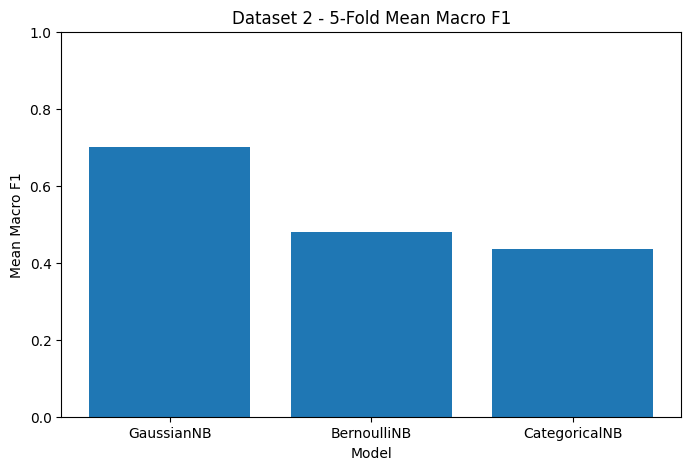

In [45]:
# Visualize mean Macro F1 across the three models
plt.figure(figsize=(8,5))

plt.bar(
    cv2_results['Model'],
    cv2_results['Mean Macro F1']
)

plt.title('Dataset 2 - 5-Fold Mean Macro F1')
plt.xlabel('Model')
plt.ylabel('Mean Macro F1')
plt.ylim(0, 1)

plt.show()

In [46]:
# Select the best model based on cross-validation Macro F1
best_model2 = cv2_results.loc[
    cv2_results['Mean Macro F1'].idxmax(),
    'Model'
]

best_score2 = cv2_results['Mean Macro F1'].max()

print("Best Dataset 2 Model:", best_model2)
print("Best Mean Macro F1:", round(best_score2, 4))

Best Dataset 2 Model: GaussianNB
Best Mean Macro F1: 0.7011


In [47]:
# Retrain the selected model using the complete training set
if best_model2 == 'GaussianNB':
    final_model2 = GaussianNB()
    final_model2.fit(X2_train_gaussian, y2_train)
    final_predictions2 = final_model2.predict(X2_test_gaussian)

elif best_model2 == 'BernoulliNB':
    final_model2 = BernoulliNB()
    final_model2.fit(X2_train_bern, y2_train)
    final_predictions2 = final_model2.predict(X2_test_bern)

elif best_model2 == 'CategoricalNB':
    final_model2 = CategoricalNB()
    final_model2.fit(X2_train_cat, y2_train)
    final_predictions2 = final_model2.predict(X2_test_cat)

print("Selected Model:", best_model2)

Selected Model: GaussianNB


In [48]:
# Predict the future customer value using GaussianNB

new_customer2 = pd.DataFrame({
    'Recency': [30],
    'Frequency': [8],
    'TotalQuantity': [500],
    'AverageOrderValue': [150],
    'Country': ['United Kingdom']
})

new_num2 = imputer2.transform(new_customer2[num_cols2])
new_num2 = scaler2.transform(new_num2)

prediction_gnb2 = gnb2.predict(new_num2)
probability_gnb2 = gnb2.predict_proba(new_num2)

print("GaussianNB Prediction:", prediction_gnb2[0])
print("GaussianNB Probability:", probability_gnb2[0])
print("GaussianNB Confidence:", round(probability_gnb2.max(), 4))

GaussianNB Prediction: 0
GaussianNB Probability: [0.86456966 0.13543034]
GaussianNB Confidence: 0.8646


In [49]:
# Predict the future customer value using BernoulliNB

new_bern2 = bern_preprocessor2.transform(new_customer2)

prediction_bnb2 = bnb2.predict(new_bern2)
probability_bnb2 = bnb2.predict_proba(new_bern2)

print("BernoulliNB Prediction:", prediction_bnb2[0])
print("BernoulliNB Probability:", probability_bnb2[0])
print("BernoulliNB Confidence:", round(probability_bnb2.max(), 4))

BernoulliNB Prediction: 0
BernoulliNB Probability: [0.77063993 0.22936007]
BernoulliNB Confidence: 0.7706


In [50]:
# Predict the future customer value using CategoricalNB

new_cat2 = encoder2.transform(new_customer2[cat_cols2])
new_cat2 = new_cat2 + 1

prediction_cnb2 = cnb2.predict(new_cat2)
probability_cnb2 = cnb2.predict_proba(new_cat2)

print("CategoricalNB Prediction:", prediction_cnb2[0])
print("CategoricalNB Probability:", probability_cnb2[0])
print("CategoricalNB Confidence:", round(probability_cnb2.max(), 4))

CategoricalNB Prediction: 0
CategoricalNB Probability: [0.76307346 0.23692654]
CategoricalNB Confidence: 0.7631


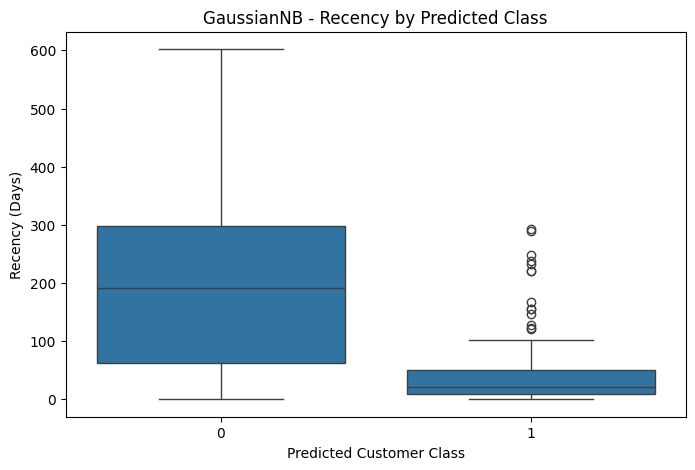

In [51]:
# Visualize customer recency distribution for GaussianNB predictions
plot_df = X2_test.copy()
plot_df['Predicted'] = y2_pred_gnb

plt.figure(figsize=(8,5))
sns.boxplot(data=plot_df, x='Predicted', y='Recency')
plt.title('GaussianNB - Recency by Predicted Class')
plt.xlabel('Predicted Customer Class')
plt.ylabel('Recency (Days)')
plt.show()

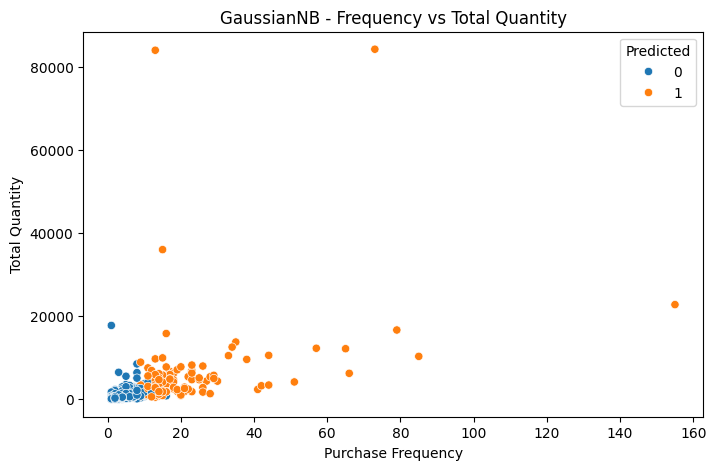

In [52]:
# Visualize frequency and quantity according to GaussianNB predictions
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=plot_df,
    x='Frequency',
    y='TotalQuantity',
    hue='Predicted'
)
plt.title('GaussianNB - Frequency vs Total Quantity')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Quantity')
plt.show()

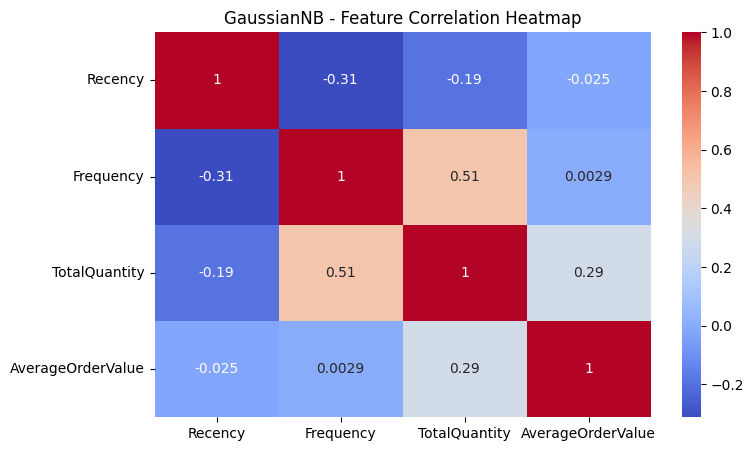

In [53]:
# Visualize correlations among numerical customer features
plt.figure(figsize=(8,5))
sns.heatmap(
    X2_test[num_cols2].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('GaussianNB - Feature Correlation Heatmap')
plt.show()

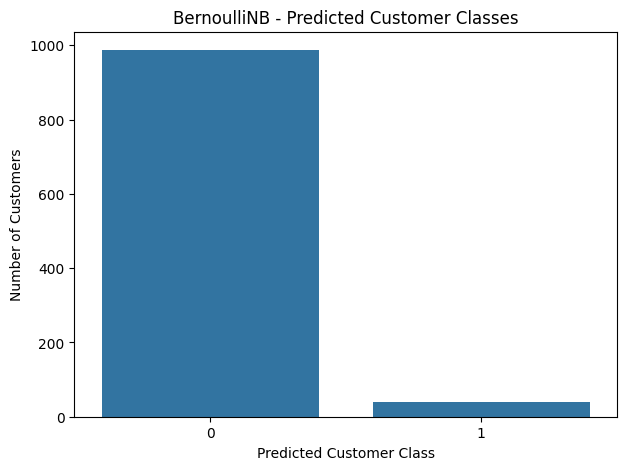

In [54]:
# Visualize the number of customers predicted in each class by BernoulliNB
plt.figure(figsize=(7,5))
sns.countplot(x=y2_pred_bnb)
plt.title('BernoulliNB - Predicted Customer Classes')
plt.xlabel('Predicted Customer Class')
plt.ylabel('Number of Customers')
plt.show()

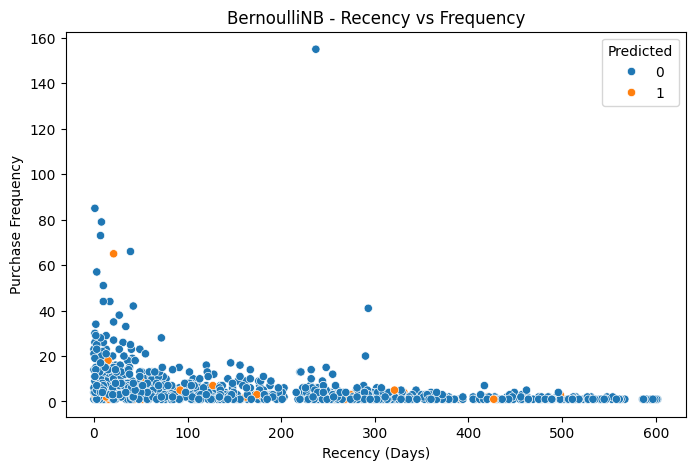

In [56]:
# Visualize customer recency and frequency according to BernoulliNB predictions
plot_df_bnb = X2_test.copy()
plot_df_bnb['Predicted'] = y2_pred_bnb

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=plot_df_bnb,
    x='Recency',
    y='Frequency',
    hue='Predicted'
)
plt.title('BernoulliNB - Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.show()

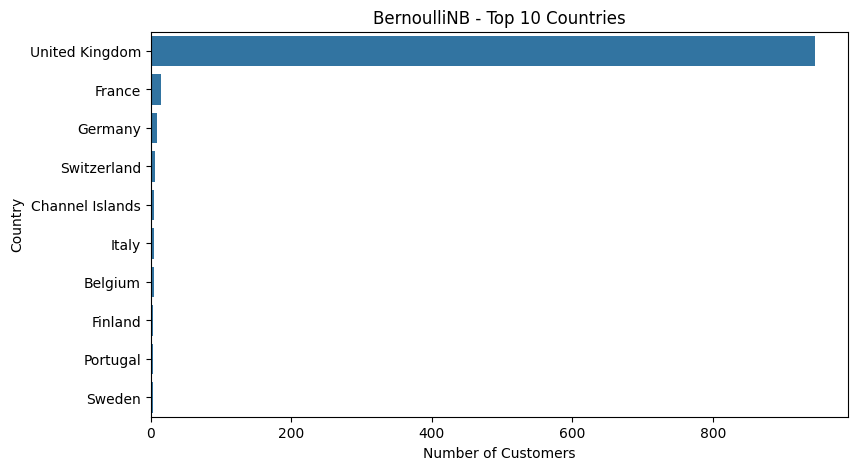

In [57]:
# Visualize the top countries represented in BernoulliNB predictions
country_counts = X2_test['Country'].value_counts().head(10)

plt.figure(figsize=(9,5))
sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)
plt.title('BernoulliNB - Top 10 Countries')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.show()

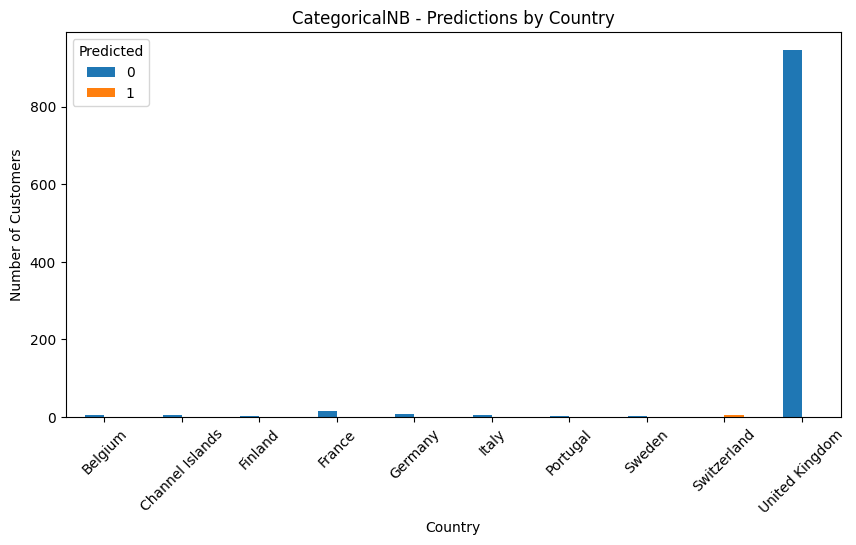

In [58]:
# Visualize CategoricalNB predictions across the top countries
plot_df_cnb = X2_test.copy()
plot_df_cnb['Predicted'] = y2_pred_cnb

top_countries = plot_df_cnb['Country'].value_counts().head(10).index

country_class = (
    plot_df_cnb[plot_df_cnb['Country'].isin(top_countries)]
    .groupby(['Country', 'Predicted'])
    .size()
    .unstack(fill_value=0)
)

country_class.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('CategoricalNB - Predictions by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

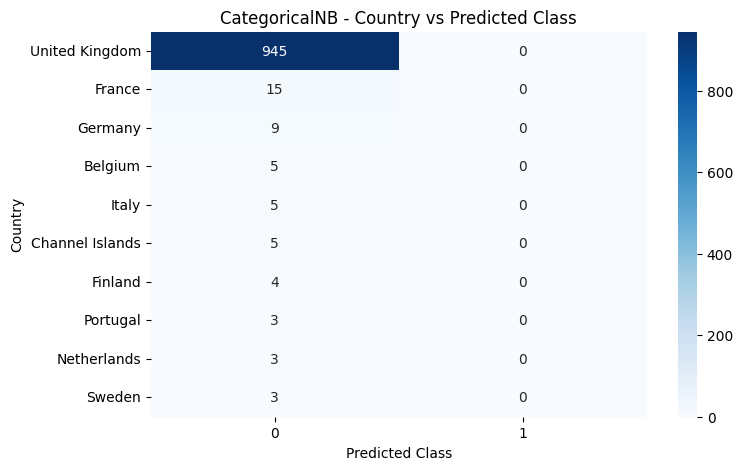

In [59]:
# Visualize the relationship between country and predicted customer class
country_heatmap = pd.crosstab(
    plot_df_cnb['Country'],
    plot_df_cnb['Predicted']
).sort_values(
    by=0,
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
sns.heatmap(
    country_heatmap,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('CategoricalNB - Country vs Predicted Class')
plt.xlabel('Predicted Class')
plt.ylabel('Country')
plt.show()

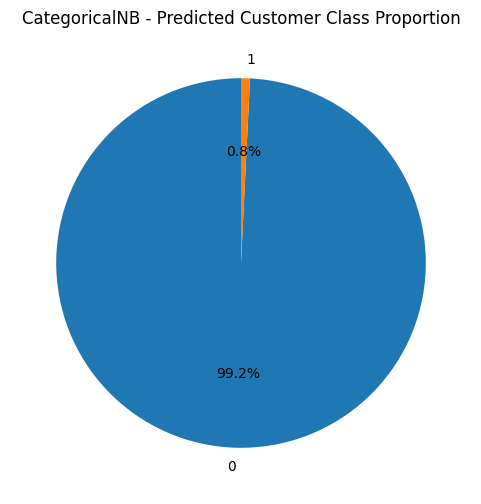

In [60]:
# Visualize the proportion of predicted customer classes
class_counts = pd.Series(y2_pred_cnb).value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('CategoricalNB - Predicted Customer Class Proportion')
plt.show()

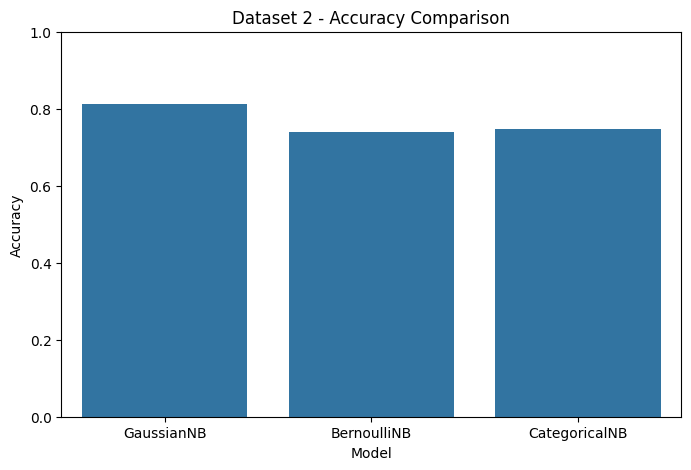

In [61]:
# Compare the accuracy of all three Naive Bayes models
plt.figure(figsize=(8,5))

sns.barplot(
    data=dataset2_results,
    x='Model',
    y='Accuracy'
)

plt.title('Dataset 2 - Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

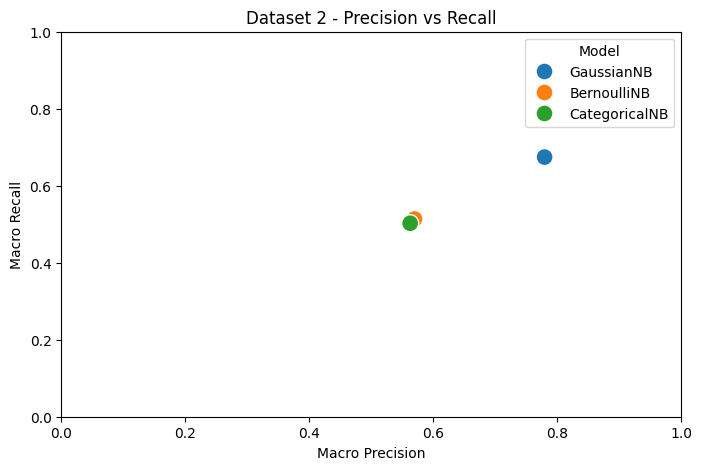

In [62]:
# Compare precision and recall of the three Naive Bayes models
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=dataset2_results,
    x='Precision',
    y='Recall',
    hue='Model',
    s=150
)

plt.title('Dataset 2 - Precision vs Recall')
plt.xlabel('Macro Precision')
plt.ylabel('Macro Recall')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

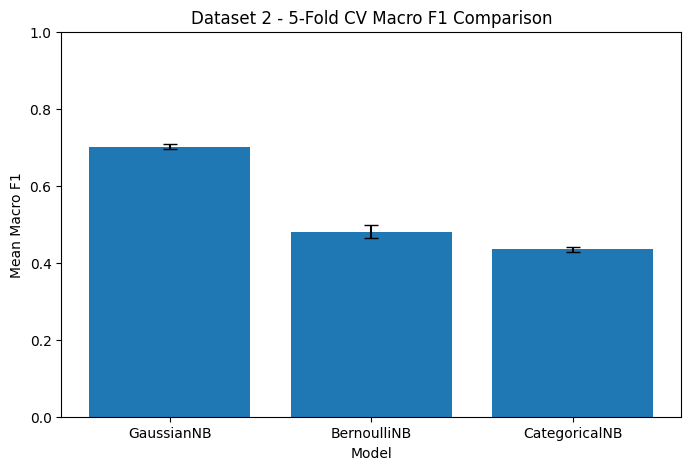

In [63]:
# Compare mean Macro F1 and standard deviation from 5-fold cross validation
plt.figure(figsize=(8,5))

plt.bar(
    cv2_results['Model'],
    cv2_results['Mean Macro F1'],
    yerr=cv2_results['SD'],
    capsize=5
)

plt.title('Dataset 2 - 5-Fold CV Macro F1 Comparison')
plt.xlabel('Model')
plt.ylabel('Mean Macro F1')
plt.ylim(0,1)
plt.show()

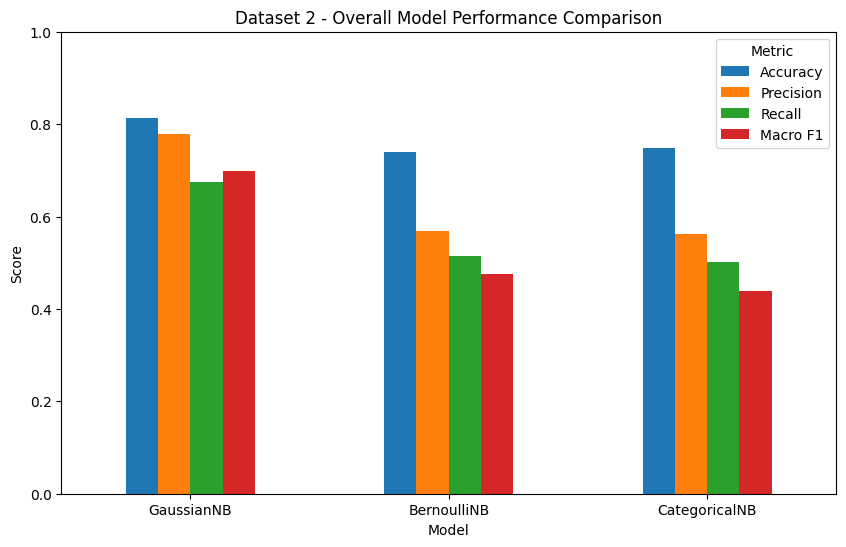

In [65]:
# Compare accuracy, precision, recall and F1-score across all models
dataset2_results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'Macro F1']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Dataset 2 - Overall Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.show()

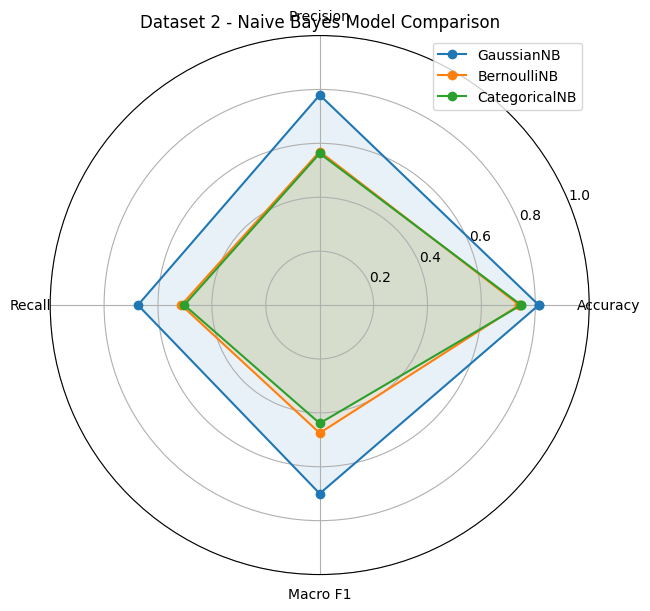

In [66]:
# Compare all major performance metrics using a radar chart
from math import pi

metrics = ['Accuracy', 'Precision', 'Recall', 'Macro F1']

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(7,7),
    subplot_kw=dict(polar=True)
)

for _, row in dataset2_results.iterrows():

    values = [
        row['Accuracy'],
        row['Precision'],
        row['Recall'],
        row['Macro F1']
    ]

    values += values[:1]

    ax.plot(angles, values, marker='o', label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0,1)

plt.title('Dataset 2 - Naive Bayes Model Comparison')
plt.legend()
plt.show()